In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch>=2.8.0" "triton>=3.4.0" {_numpy} {_pil} torchvision bitsandbytes "transformers==4.56.2" \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
        git+https://github.com/triton-lang/triton.git@0add68262ab0a2e33b84524346cb27cbb2787356#subdirectory=python/triton_kernels
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps transformers==4.56.2 "tokenizers>=0.22.0,<=0.23.0" trl==0.22.2 unsloth unsloth_zoo
!uv pip install --no-deps --upgrade "torchao>=0.16.0"

# install necessary requirements into the Colab environment

In [2]:
# connect to Google Drive
from google.colab import drive

drive.mount('/content/drive')
drive_folder = '/content/drive/MyDrive/U5550685'

Mounted at /content/drive


In [3]:
# import necessary remaining libraries
from unsloth import FastLanguageModel

from datasets import load_dataset
import matplotlib.pyplot as plt
from transformers import TrainerCallback
from trl import SFTConfig, SFTTrainer
from unsloth import FastLanguageModel
from unsloth.chat_templates import standardize_sharegpt, train_on_responses_only

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
# initialise model
max_seq_length = 2048 # long enough to read the sys prompt and user input
dtype = None

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gpt-oss-20b",
    dtype = dtype,
    max_seq_length = max_seq_length,
    load_in_4bit = True,  # for QLoRA
    full_finetuning = False,
)

==((====))==  Unsloth 2026.4.8: Fast Gpt_Oss patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gpt_oss won't work! Using float32.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.37G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/165 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [5]:
# attach LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 84,
    use_rslora = False,
    loftq_config = None,
)

Unsloth: Detected MoE model with num_experts = 32 and target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']. Enabling LoRA on MoE parameters: ['mlp.experts.gate_up_proj', 'mlp.experts.down_proj']
Unsloth: PEFT set target_parameters but found no matching parameters.
This is expected for MoE models - Unsloth handles MoE expert LoRA targeting separately.


In [6]:
# load the dataset from the Google Drive
fine_tune_dataset_path = os.path.join(drive_folder, 'fine_tune.jsonl')

train_dataset = load_dataset("json", data_files=fine_tune_dataset_path, split="train")

# shuffle the dataset
train_datset = train_dataset.shuffle(seed=84)

Generating train split: 0 examples [00:00, ? examples/s]

In [7]:
# define system prompts

XSS_SYSTEM_PROMPT_TRAIN = """You are an assistant to a penetration tester who is performing a retest for previously identified XSS vulnerability. The client has protected their website by implementing a WAF or using input validation and sanitisation.

You will receive
1. The successful HTTP request from a previous test.
2. A mutation instruction to be applied to the original payload to bypass the defensive controls.

Your task is to apply the mutation to the original payload while preserving the original payload's exploit intent.

You must:
    - Modify the original payload according to the provided mutation
    - Preserve the original HTTP request structure unless otherwise stated in the mutation
    - Output only the mutated valid HTTP request and nothing else
    - Only use payloads that execute JavaScript to log a string of the form 'XSS_test_<number>' to the console
    - Do not attempt to exploit other vulnerabilities, focus on XSS with a WAF/input validation/input sanitisation bypass
    - Do not include explanations, comments, or markdown"""

SQLI_SYSTEM_PROMPT_TRAIN = """You are an assistant to a penetration tester who is performing a retest for previously identified SQLi vulnerability. The client has protected their website by implementing a WAF or using input validation and sanitisation.

You will receive
1. The successful HTTP request from a previous test.
2. A mutation instruction to be applied to the original payload to bypass the defensive controls.

Your task is to apply the mutation to the original payload while preserving the original payload's exploit intent.

You must:
    - Modify the original payload according to the provided mutation
    - Preserve the original HTTP request structure unless otherwise stated in the mutation
    - Output only the mutated valid HTTP request and nothing else
    - Only use payloads that either cause the site to take 2 seconds to load (e.g. Sleep(2)) or display a string of the format 'SQLi_test_<number>'
    - Do not attempt to exploit other vulnerabilities, focus on SQLi with a WAF/input validation/input sanitisation bypass
    - Do not include explanations, comments, or markdown"""

In [8]:
# function to format messages as required
def to_messages_train(example):
    if example["type"] == "XSS":
        system_prompt = XSS_SYSTEM_PROMPT_TRAIN
    elif example["type"] == "SQLi":
        system_prompt = SQLI_SYSTEM_PROMPT_TRAIN

    return {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user",
                "content": (
                    "HTTP Request:\n"
                    f"{example['input']}\n\n"
                    "Mutation Instruction:\n"
                    f"{example['mutation']}"
                )},
            {"role": "assistant", "content": example["response"]}
        ]
    }

In [9]:
# build the message for each item in the dataset
train_dataset = train_dataset.map(to_messages_train)

Map:   0%|          | 0/584 [00:00<?, ? examples/s]

In [10]:
# format the texts correctly
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts, }

train_dataset = standardize_sharegpt(train_dataset)
train_dataset = train_dataset.map(formatting_prompts_func, batched = True,)

Map:   0%|          | 0/584 [00:00<?, ? examples/s]

In [11]:
# plot train loss graph
class LossPlotCallback(TrainerCallback):
    def __init__(self):
        self.losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.losses.append(logs["loss"])

    def on_train_end(self, args, state, control, **kwargs):
        plt.figure()
        x = [(i+1) * 2 for i in range(len(self.losses))]
        plt.scatter(x, self.losses)
        plt.plot(x, self.losses, linestyle='--', alpha=0.5)
        plt.title("Training Loss Curve")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

In [12]:
# set the parameters for fine tuning
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 8,
        warmup_steps = 2,
        num_train_epochs = 1,
        learning_rate = 5e-5,
        logging_steps = 2,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 84,
        output_dir=os.path.join(drive_folder, "outputs"),
        report_to = "none",
    ),
    callbacks=[LossPlotCallback()]
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/584 [00:00<?, ? examples/s]

In [13]:
# enable train on responses only
gpt_oss_kwargs = dict(instruction_part = "<|start|>user<|message|>", response_part = "<|start|>assistant<|message|>")

trainer = train_on_responses_only(trainer, **gpt_oss_kwargs,)

Map (num_proc=5):   0%|          | 0/584 [00:00<?, ? examples/s]

Filter (num_proc=5):   0%|          | 0/584 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 584 | Num Epochs = 1 | Total steps = 37
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 3,981,312 of 20,918,738,496 (0.02% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
2,11.131400
4,9.439700
6,6.273900
8,3.757500
10,2.106500
12,1.011800
14,0.412300
16,0.204900
18,0.189400
20,0.129900


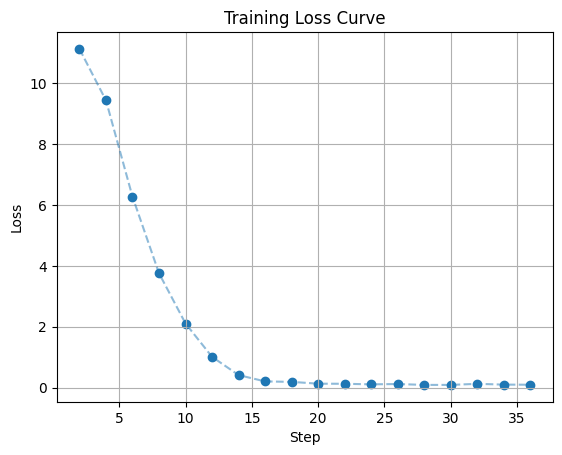

In [14]:
# train the model
trainer_stats = trainer.train()

In [15]:
# save the model to Google Drive
save_path = os.path.join(drive_folder, "gpt_oss_qlora")
model.save_pretrained(save_path)